# Лаб.5и6 Ульченко 24ВВИм1

### Задание: выделить перец

(np.float64(-0.5), np.float64(767.5), np.float64(511.5), np.float64(-0.5))

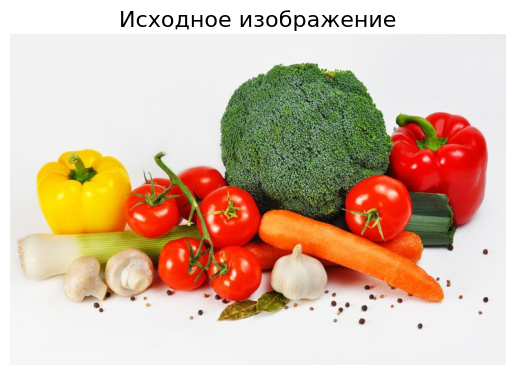

In [138]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

plt.imshow(cv.cvtColor(cv.imread('vegetables.jpg'), cv.COLOR_BGR2RGB))
plt.title('Исходное изображение', fontsize=16)
plt.axis('off')

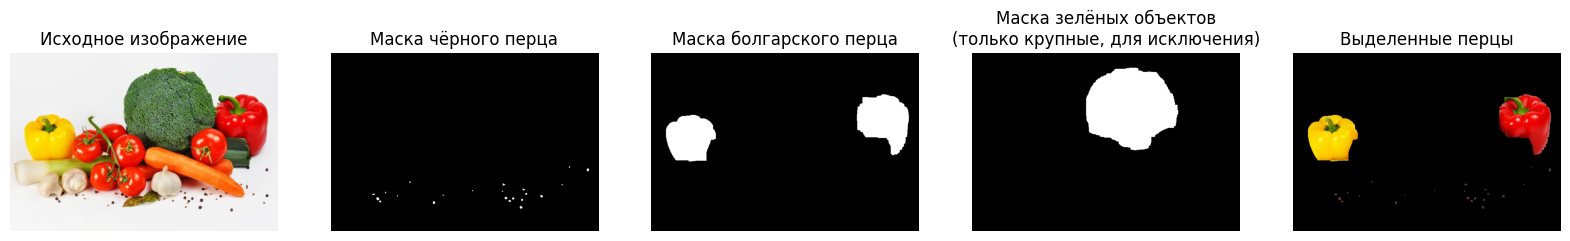

True

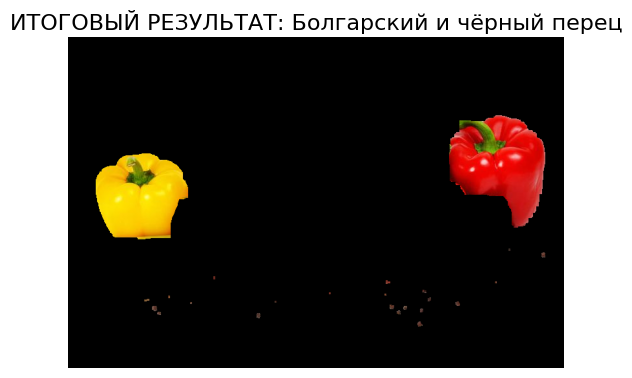

In [142]:
image = cv.imread('vegetables.jpg')
hsv_image = cv.cvtColor(image, cv.COLOR_BGR2HSV)

lower_brown = np.array([2, 40, 40])
upper_brown = np.array([15, 190, 150])
mask_black = cv.inRange(hsv_image, lower_brown, upper_brown)
kernel_small = np.ones((3, 3), np.uint8)
mask_black = cv.morphologyEx(mask_black, cv.MORPH_OPEN, kernel_small, iterations=1)
min_area_black = 5
max_area_black = 150
num_labels, labels, stats, _ = cv.connectedComponentsWithStats(mask_black, connectivity=8)
mask_black_filtered = np.zeros_like(mask_black)
for i in range(1, num_labels):
    area = stats[i, cv.CC_STAT_AREA]
    if min_area_black < area < max_area_black:
        mask_black_filtered[labels == i] = 255


lower_red1 = np.array([0, 95, 95])
upper_red1 = np.array([1, 250, 250])
lower_red2 = np.array([170, 200, 100])
upper_red2 = np.array([180, 235, 235])
lower_yellow = np.array([20, 220, 100])
upper_yellow = np.array([37, 255, 255])
mask_red1 = cv.inRange(hsv_image, lower_red1, upper_red1)
mask_red2 = cv.inRange(hsv_image, lower_red2, upper_red2)
mask_red = cv.bitwise_or(mask_red1, mask_red2)
mask_yellow = cv.inRange(hsv_image, lower_yellow, upper_yellow)
mask_bell_raw = cv.bitwise_or(mask_red, mask_yellow)
kernel_bell = np.ones((7, 7), np.uint8)
mask_bell = cv.morphologyEx(mask_bell_raw, cv.MORPH_CLOSE, kernel_bell, iterations=3)  
mask_bell = cv.morphologyEx(mask_bell, cv.MORPH_OPEN, kernel_bell, iterations=1)       
min_area_bell = 12000
max_area_bell = 80000
num_labels_bell, labels_bell, stats_bell, _ = cv.connectedComponentsWithStats(mask_bell, connectivity=8)
mask_bell_filtered = np.zeros_like(mask_bell)
for i in range(1, num_labels_bell):
    area = stats_bell[i, cv.CC_STAT_AREA]
    if min_area_bell < area < max_area_bell:
        mask_bell_filtered[labels_bell == i] = 255


lower_green = np.array([35, 50, 50])
upper_green = np.array([85, 255, 255])
mask_green_raw = cv.inRange(hsv_image, lower_green, upper_green)
mask_green_raw = cv.morphologyEx(mask_green_raw, cv.MORPH_CLOSE, kernel_bell, iterations=2)
mask_green_raw = cv.morphologyEx(mask_green_raw, cv.MORPH_OPEN, kernel_bell, iterations=1)
num_labels_green, labels_green, stats_green, _ = cv.connectedComponentsWithStats(mask_green_raw, connectivity=8)
mask_green_filtered = np.zeros_like(mask_green_raw)
for i in range(1, num_labels_green):
    area = stats_green[i, cv.CC_STAT_AREA]
    if min_area_bell < area < max_area_bell:
        mask_green_filtered[labels_green == i] = 255
mask_bell_filtered = cv.bitwise_and(mask_bell_filtered, cv.bitwise_not(mask_green_filtered))


mask_total = cv.bitwise_or(mask_black_filtered, mask_bell_filtered)
result = cv.bitwise_and(image, image, mask=mask_total)

plt.figure(figsize=(20, 12))
plt.subplot(1, 5, 1)
plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
plt.title('Исходное изображение')
plt.axis('off')
plt.subplot(1, 5, 2)
plt.imshow(mask_black_filtered, cmap='gray')
plt.title('Маска чёрного перца')
plt.axis('off')
plt.subplot(1, 5, 3)
plt.imshow(mask_bell_filtered, cmap='gray')
plt.title('Маска болгарского перца')
plt.axis('off')
plt.subplot(1, 5, 4)
plt.imshow(mask_green_filtered, cmap='gray')
plt.title('Маска зелёных объектов\n(только крупные, для исключения)')
plt.axis('off')
plt.subplot(1, 5, 5)
plt.imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
plt.title('Выделенные перцы')
plt.axis('off')
plt.show()

plt.imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
plt.title('ИТОГОВЫЙ РЕЗУЛЬТАТ: Болгарский и чёрный перец', fontsize=16)
plt.axis('off')
output_filename = 'result.jpg'  
cv.imwrite(output_filename, result)